
# Análisis Exploratorio de Datos (EDA) - US Accidents

Este notebook tiene un propósito específico: apoyar el diseño del dashboard y justificar las decisiones de visualización basadas en los conceptos de abstracción de datos, marcas y canales.

No busca realizar un análisis estadístico exhaustivo, sino identificar patrones relevantes para las tareas del proyecto.


In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

df = pd.read_parquet("processed/US_Accidents_Processed.parquet")

print("Dimensiones:", df.shape)

df.head()


Dimensiones: (500000, 45)


,ID,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,City,County,State,Temperature(F),...,Weekday,Is_Weekend,Season,Weather_Group,YearMonth,Time_Period,Weekday_Order,Lat_Grid,Lng_Grid,Duration_Minutes
0,A-23094,2,2016-10-04 18:24:11,2016-10-04 18:53:25,37.374687,-121.932213,San Jose,Santa Clara,CA,66.0,...,Tuesday,False,Fall,Cloudy,2016-10,Noche,2,37.4,-121.9,29.233333
1,A-3471060,3,2016-11-16 13:44:44,2016-11-16 19:44:44,41.806200,-72.660460,Windsor,Hartford,CT,57.9,...,Wednesday,False,Fall,Cloudy,2016-11,Tarde,3,41.8,-72.7,360.000000
2,A-3517455,3,2016-04-07 13:45:26,2016-04-07 19:45:26,40.012570,-75.058835,Philadelphia,Philadelphia,PA,59.0,...,Thursday,False,Spring,Rain,2016-04,Tarde,4,40.0,-75.1,360.000000
3,A-187243,3,2016-09-20 08:12:53,2016-09-20 08:42:32,42.220123,-83.440025,Belleville,Wayne,MI,68.0,...,Tuesday,False,Fall,Cloudy,2016-09,Mañana,2,42.2,-83.4,29.650000
4,A-3480211,2,2016-10-03 05:26:03,2016-10-03 11:26:03,37.359432,-77.889230,Amelia Court House,Amelia,VA,59.0,...,Monday,False,Fall,Fog,2016-10,Madrugada,1,37.4,-77.9,360.000000



# 1. Comprensión y Calidad de los Datos

Esta sección permite identificar los atributos disponibles y verificar la calidad general de los datos antes de diseñar visualizaciones.


In [5]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ID                 500000 non-null  str           
 1   Severity           500000 non-null  int64         
 2   Start_Time         500000 non-null  datetime64[us]
 3   End_Time           500000 non-null  datetime64[ns]
 4   Start_Lat          500000 non-null  float64       
 5   Start_Lng          500000 non-null  float64       
 6   City               499980 non-null  str           
 7   County             500000 non-null  str           
 8   State              500000 non-null  str           
 9   Temperature(F)     500000 non-null  float64       
 10  Wind_Chill(F)      370847 non-null  float64       
 11  Humidity(%)        488676 non-null  float64       
 12  Pressure(in)       490891 non-null  float64       
 13  Visibility(mi)     488543 non-null  float64       
 14 

In [6]:

(
    df.isnull()
      .mean()
      .sort_values(ascending=False)
      .head(20)
)


Precipitation(in)    0.284988
Wind_Chill(F)        0.258306
Wind_Speed(mph)      0.074108
Visibility(mi)       0.022914
Humidity(%)          0.022648
Pressure(in)         0.018218
Sunrise_Sunset       0.002864
City                 0.000040
Severity             0.000000
Start_Lat            0.000000
End_Time             0.000000
Start_Time           0.000000
ID                   0.000000
Temperature(F)       0.000000
Start_Lng            0.000000
County               0.000000
State                0.000000
Amenity              0.000000
Bump                 0.000000
Crossing             0.000000
dtype: float64

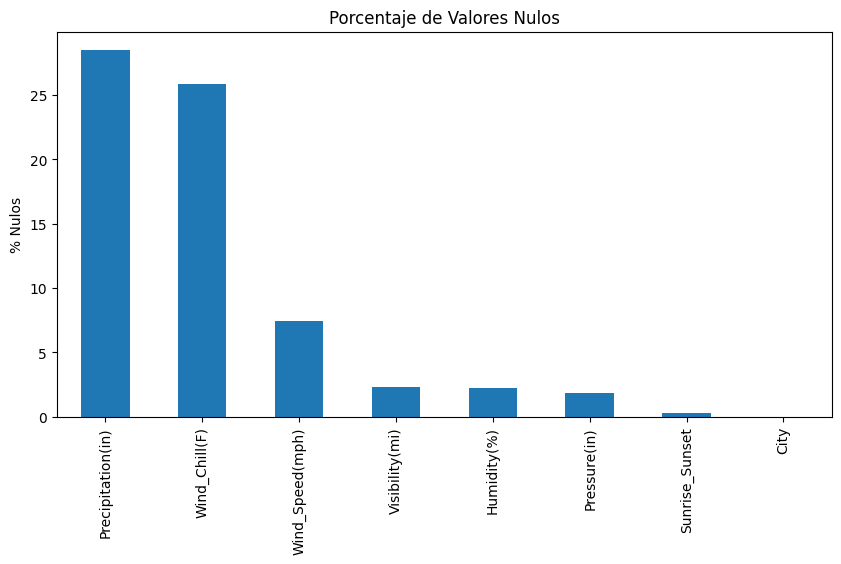

In [17]:
nulls = (
    df.isnull()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

nulls = nulls[nulls > 0]

plt.figure(figsize=(10,5))

nulls.plot(kind="bar")

plt.title(
    "Porcentaje de Valores Nulos"
)

plt.ylabel("% Nulos")

plt.show()

In [18]:
critical_columns = [
    "State",
    "Weather_Group",
    "Year",
    "Month",
    "Hour",
    "Weekday",
    "Severity"
]

df[critical_columns].isnull().sum()

State            0
Weather_Group    0
Year             0
Month            0
Hour             0
Weekday          0
Severity         0
dtype: int64

In [19]:
df["Weather_Group"].value_counts()

Weather_Group
Other     217758
Cloudy    180088
Clear      51907
Rain       32532
Snow       10662
Fog         7053
Name: count, dtype: int64

In [20]:
df["Severity"].value_counts()

Severity
2    398162
3     84206
4     13223
1      4409
Name: count, dtype: int64

In [21]:
df["State"].nunique()

49

In [22]:
df["State"].value_counts().head()

State
CA    112432
FL     57256
TX     37899
SC     24531
NY     22513
Name: count, dtype: int64

In [23]:
df["Duration_Minutes"].describe()

count    5.000000e+05
mean     4.319518e+02
std      1.343252e+04
min      3.000000e+00
25%      3.155000e+01
50%      7.491667e+01
75%      1.251333e+02
max      2.236280e+06
Name: Duration_Minutes, dtype: float64


# 2. Distribución General

Análisis básico para entender el volumen de datos y la distribución de severidad.


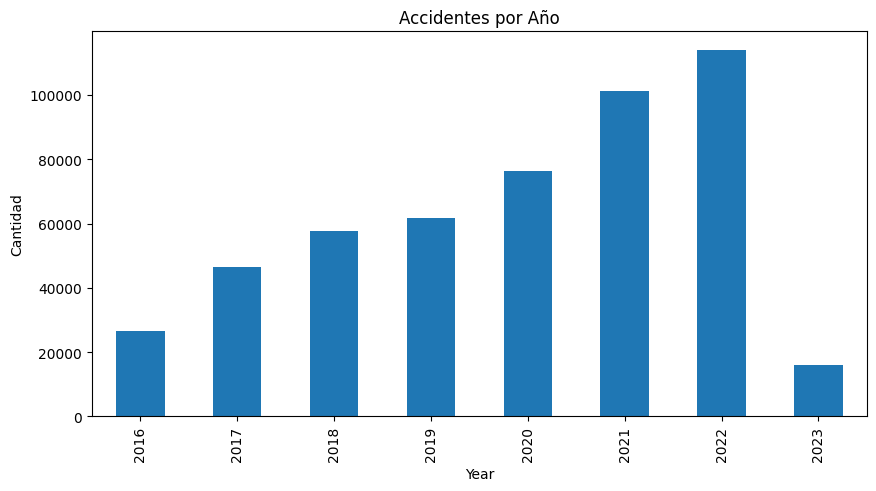

In [7]:

accidents_per_year = (
    df["Year"]
      .value_counts()
      .sort_index()
)

plt.figure(figsize=(10,5))
accidents_per_year.plot(kind="bar")
plt.title("Accidentes por Año")
plt.ylabel("Cantidad")
plt.show()


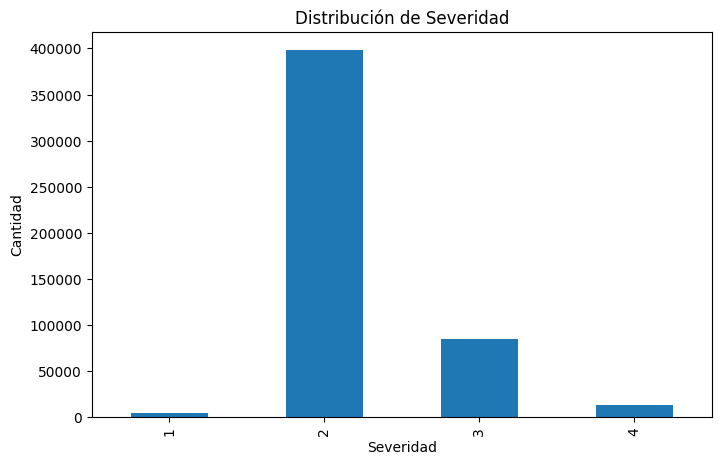

In [8]:

plt.figure(figsize=(8,5))

(
    df["Severity"]
      .value_counts()
      .sort_index()
      .plot(kind="bar")
)

plt.title("Distribución de Severidad")
plt.xlabel("Severidad")
plt.ylabel("Cantidad")
plt.show()


In [24]:
other_weather = df[
    df["Weather_Group"] == "Other"
]

print(
    f"Registros Other: {len(other_weather):,}"
)

print(
    f"Porcentaje: {len(other_weather)/len(df)*100:.2f}%"
)

Registros Other: 217,758
Porcentaje: 43.55%


In [25]:
(
    df.loc[
        df["Weather_Group"] == "Other",
        "Weather_Condition"
    ]
    .value_counts()
    .head(50)
)

Weather_Condition
Fair                              166014
Overcast                           24887
Unknown                            11248
Haze                                4924
Fair / Windy                        2269
Light Drizzle                       1459
Thunder in the Vicinity             1131
T-Storm                             1028
Thunder                              953
Smoke                                829
Wintry Mix                           708
Heavy T-Storm                        593
Drizzle                              312
Thunderstorm                         278
N/A Precipitation                    219
Mist                                 216
Showers in the Vicinity              106
Haze / Windy                          97
Light Freezing Drizzle                87
Heavy T-Storm / Windy                 71
T-Storm / Windy                       61
Thunder / Windy                       45
Heavy Drizzle                         26
Light Drizzle / Windy                 2

In [26]:
sorted(
    df.loc[
        df["Weather_Group"] == "Other",
        "Weather_Condition"
    ]
    .dropna()
    .unique()
)

['Blowing Dust',
 'Blowing Dust / Windy',
 'Drizzle',
 'Drizzle / Windy',
 'Fair',
 'Fair / Windy',
 'Freezing Drizzle',
 'Hail',
 'Haze',
 'Haze / Windy',
 'Heavy Drizzle',
 'Heavy Ice Pellets',
 'Heavy Sleet',
 'Heavy T-Storm',
 'Heavy T-Storm / Windy',
 'Ice Pellets',
 'Light Drizzle',
 'Light Drizzle / Windy',
 'Light Freezing Drizzle',
 'Light Hail',
 'Light Haze',
 'Light Ice Pellets',
 'Light Sleet',
 'Mist',
 'N/A Precipitation',
 'Overcast',
 'Sand',
 'Sand / Dust Whirlwinds',
 'Sand / Dust Whirlwinds / Windy',
 'Showers in the Vicinity',
 'Sleet',
 'Sleet / Windy',
 'Small Hail',
 'Smoke',
 'Smoke / Windy',
 'Squalls',
 'Squalls / Windy',
 'T-Storm',
 'T-Storm / Windy',
 'Thunder',
 'Thunder / Windy',
 'Thunder / Wintry Mix',
 'Thunder in the Vicinity',
 'Thunderstorm',
 'Unknown',
 'Widespread Dust',
 'Widespread Dust / Windy',
 'Wintry Mix',
 'Wintry Mix / Windy']

In [27]:
other_summary = (
    df.loc[
        df["Weather_Group"] == "Other",
        "Weather_Condition"
    ]
    .value_counts()
    .reset_index()
)

other_summary.columns = [
    "Weather_Condition",
    "Count"
]

other_summary.head(30)

,Weather_Condition,Count
0,Fair,166014
1,Overcast,24887
2,Unknown,11248
3,Haze,4924
4,Fair / Windy,2269
5,Light Drizzle,1459
6,Thunder in the Vicinity,1131
7,T-Storm,1028
8,Thunder,953
9,Smoke,829



# 3. Estados con Mayor Número de Accidentes

Tarea:

- Identificar estados con mayor número de accidentes.

Posible visualización final:

- Gráfico de barras.
- Marca principal: longitud.
- Canal: posición.


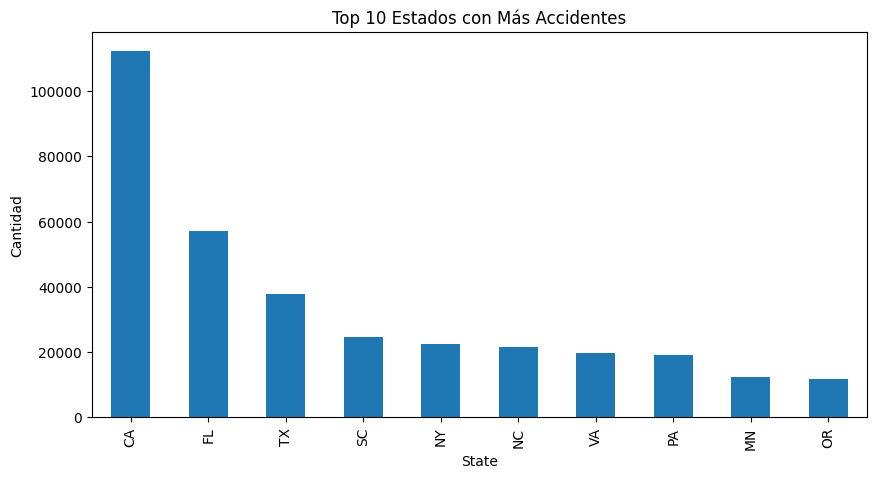

In [9]:

top_states = (
    df["State"]
      .value_counts()
      .head(10)
)

plt.figure(figsize=(10,5))

top_states.plot(kind="bar")

plt.title("Top 10 Estados con Más Accidentes")
plt.ylabel("Cantidad")
plt.show()



# 4. Distribución Geográfica y Hotspots

Tarea:

- Detectar zonas geográficas de alta concentración de accidentes.

Posible visualización final:

- Mapa.
- Heatmap geográfico.


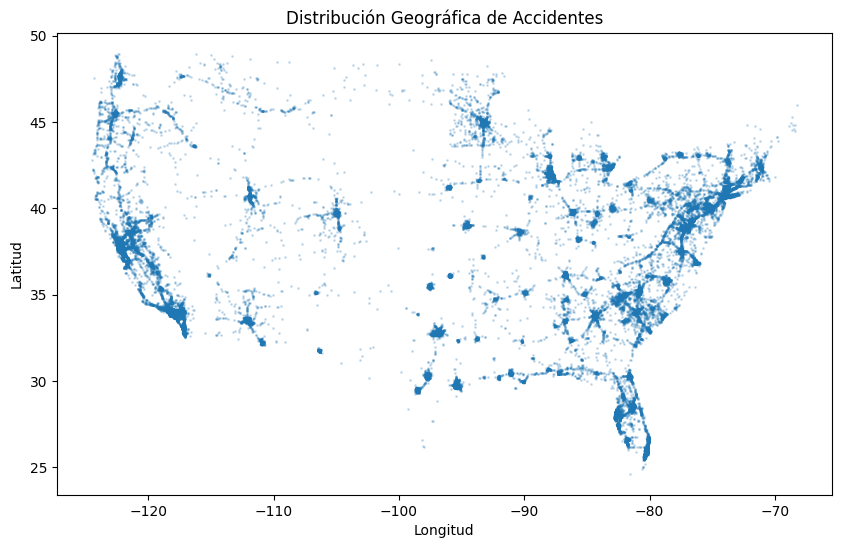

In [10]:

sample_geo = df.sample(
    min(50000, len(df)),
    random_state=42
)

plt.figure(figsize=(10,6))

plt.scatter(
    sample_geo["Start_Lng"],
    sample_geo["Start_Lat"],
    s=1,
    alpha=0.2
)

plt.title("Distribución Geográfica de Accidentes")
plt.xlabel("Longitud")
plt.ylabel("Latitud")

plt.show()


In [11]:

hotspots = (
    df.groupby(
        ["Lat_Grid", "Lng_Grid"]
    )
    .size()
    .reset_index(name="Accidents")
)

hotspots.nlargest(
    10,
    "Accidents"
)


,Lat_Grid,Lng_Grid,Accidents
46,25.9,-80.2,3493
3699,34.0,-118.2,2545
30,25.7,-80.4,2225
5394,35.2,-80.8,2127
2524,32.8,-96.8,2126
6183,35.8,-78.6,2123
3572,33.9,-118.3,2113
12416,40.8,-73.9,2091
3698,34.0,-118.3,2047
37,25.8,-80.3,1863



# 5. Horarios con Mayor Ocurrencia

Tareas:

- Encontrar horarios con más accidentes.
- Analizar patrones por hora.


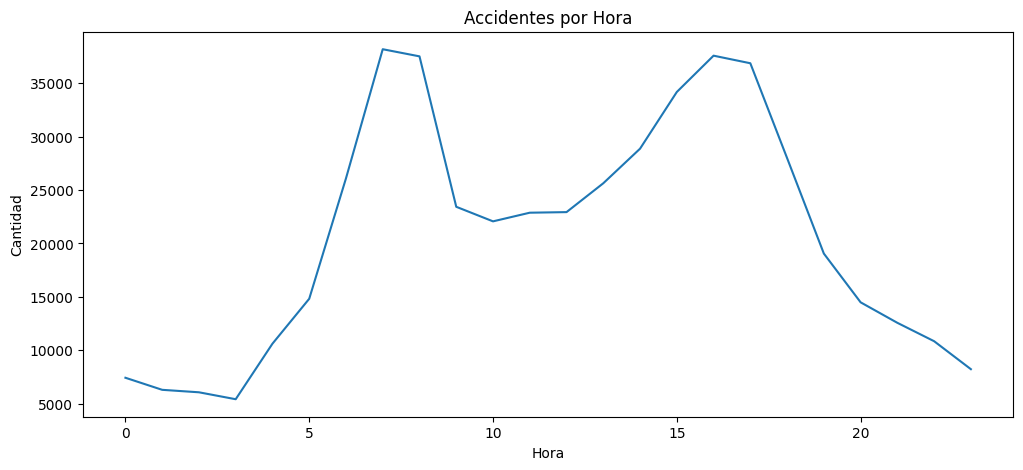

In [12]:

accidents_by_hour = (
    df["Hour"]
      .value_counts()
      .sort_index()
)

plt.figure(figsize=(12,5))

accidents_by_hour.plot()

plt.title("Accidentes por Hora")
plt.xlabel("Hora")
plt.ylabel("Cantidad")

plt.show()



# 6. Patrones por Día y Hora

Esta visualización es candidata directa para el dashboard porque combina dos dimensiones temporales importantes.


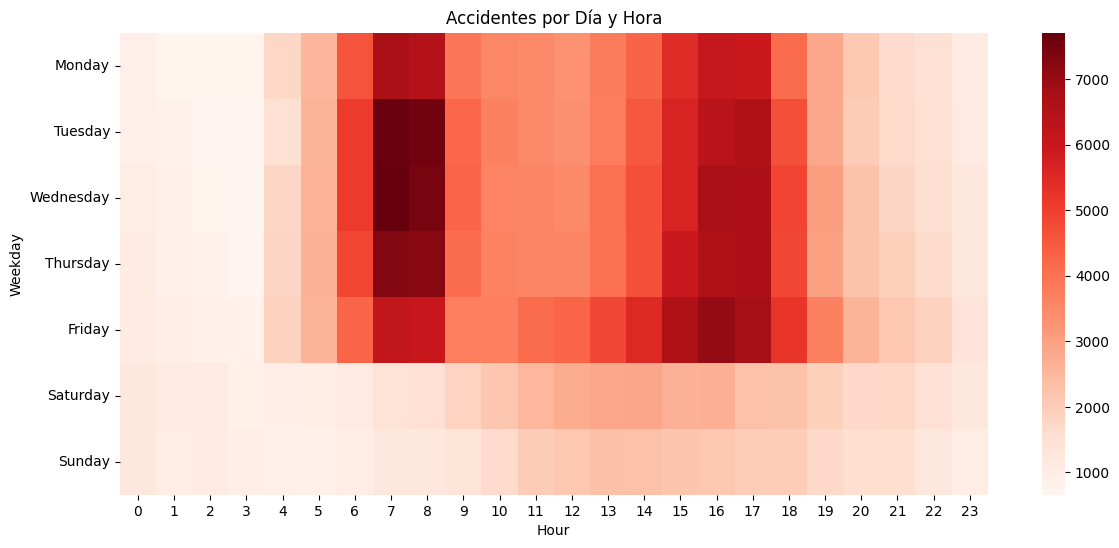

In [13]:

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

heatmap_data = pd.crosstab(
    df["Weekday"],
    df["Hour"]
)

heatmap_data = heatmap_data.reindex(
    weekday_order
)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="Reds"
)

plt.title("Accidentes por Día y Hora")

plt.show()



# 7. Evolución Temporal

Tarea:

- Analizar la evolución temporal de los accidentes.


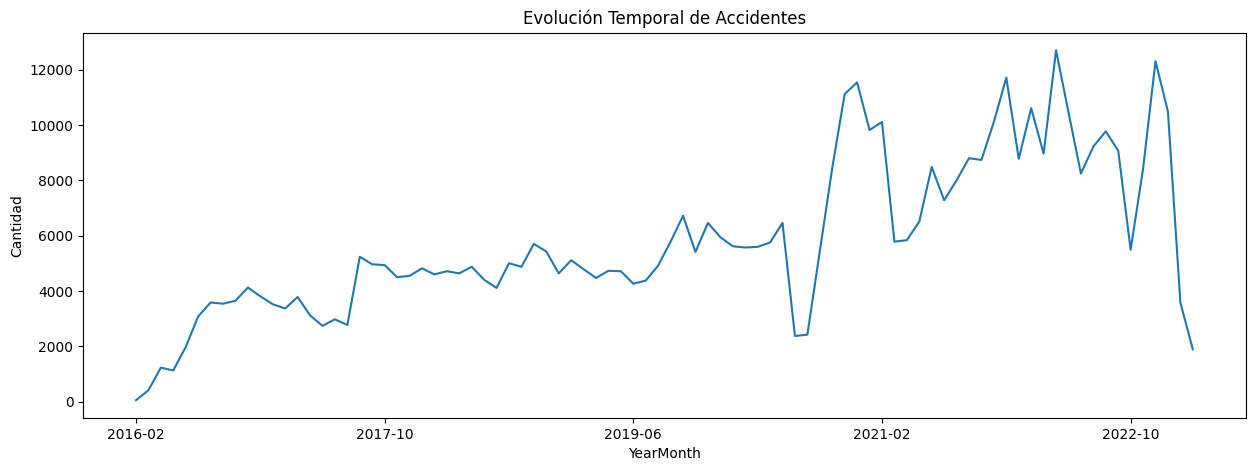

In [14]:

monthly = (
    df.groupby("YearMonth")
      .size()
)

plt.figure(figsize=(15,5))

monthly.plot()

plt.title("Evolución Temporal de Accidentes")
plt.ylabel("Cantidad")

plt.show()



# 8. Clima y Severidad

Tarea:

- Evaluar la relación entre clima y severidad.


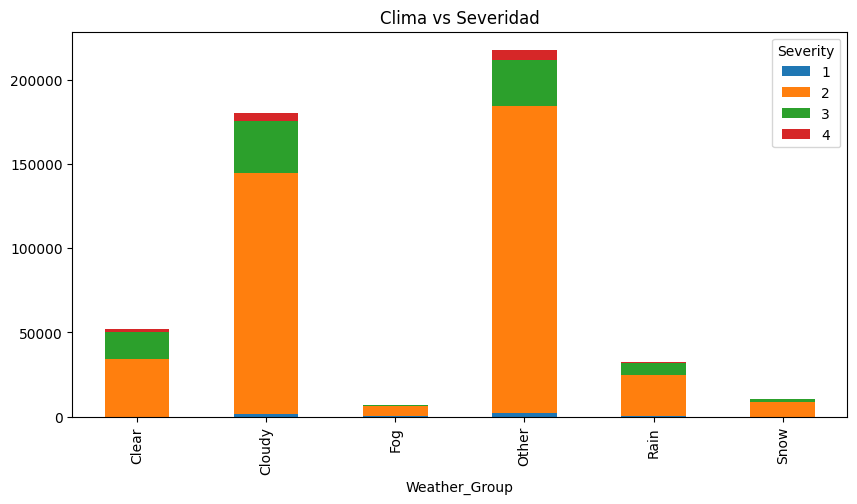

In [15]:

weather_severity = pd.crosstab(
    df["Weather_Group"],
    df["Severity"]
)

weather_severity.plot(
    kind="bar",
    stacked=True,
    figsize=(10,5)
)

plt.title("Clima vs Severidad")

plt.show()



# 9. Severidad por Estado

Tarea:

- Comparar la severidad entre distintos estados.


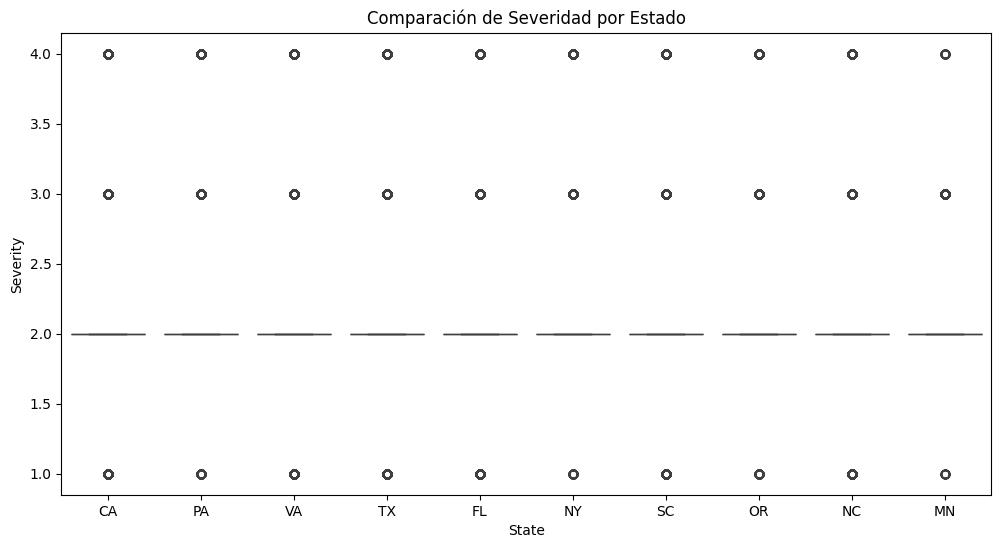

In [16]:

top_states = (
    df["State"]
      .value_counts()
      .head(10)
      .index
)

severity_state = (
    df[df["State"].isin(top_states)]
)

plt.figure(figsize=(12,6))

sns.boxplot(
    data=severity_state,
    x="State",
    y="Severity"
)

plt.title("Comparación de Severidad por Estado")

plt.show()



# 10. Conclusiones para el Dashboard

| Tarea | Visualización candidata | Marca principal | Canal |
|---------|---------|---------|---------|
| Estados con más accidentes | Barras | Longitud | Posición |
| Hotspots geográficos | Mapa | Posición | Latitud/Longitud |
| Accidentes por hora | Línea | Posición | X-Y |
| Día y hora | Heatmap | Color | Intensidad |
| Evolución temporal | Línea temporal | Posición | Tiempo |
| Clima y severidad | Barras apiladas | Color | Categoría |
| Severidad por estado | Boxplot | Posición | Distribución |
